## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

- **Oscar Khaing:** Conceptualization, Background research, Methodology, Writing – original draft, Project administration  
- **Camila Zacharko:** Data curation, Analysis, Visualization  
- **Carlos Iskandar:** Analysis, Visualization, Software  
- **Abigail Chang:** Background research, Writing – review & editing  
- **Alyssa Rivera:** Experimental investigation, Writing – review & editing


# Research Question

How does court surface (Hard, Clay, Grass) affect (1) upset probability and (2) the predictive power of player rankings in professional tennis matches?

Specifically, we will examine:

    Whether the probability of an upset (lower-ranked player defeating higher-ranked player) differs significantly across surfaces.

    Whether ranking difference predicts match outcomes equally well on all surfaces.

Key variables include:

    Surface (categorical)

    Rank_1, Rank_2 (used to compute ranking difference)

    Winner (binary outcome)

    Odds (used as a secondary comparison baseline)

Controls

    Tournament Type (Grand Slams, Masters 1000, ATP 500/250) this will help isolate whether upsets are caused by court surface itself or differing levels of pressure and player motivation.

    Match Format (Best of 3 vs Best of 5) because Grand Slams hold best-of-5 matches and standard ATP matches are best-of-3 we will be using "best of" as a control variable, accounting for longer matches typically reducing the probability of an upsets by allowing a higher level player more time to recover from a slow start.

This project combines statistical inference (testing differences in upset rates across surfaces) with a prediction task (logistic regression models estimating match outcomes from ranking differences, with and without surface information). Model performance metrics such as accuracy and AUC will be used to quantify how much predictive power surface adds.

## Background and Prior Work

Professional tennis is played across multiple court surfaces—primarily hard, clay, and grass—and these surfaces materially change how matches unfold. The International Tennis Federation (ITF) formalizes these differences through its Court Pace Rating system, which classifies surfaces based on measured ball speed and bounce characteristics. These classifications reflect meaningful physical differences in gameplay, such as rally length and serve effectiveness, and provide an official basis for treating surface as a structural variable in match outcomes.1

Sports science research supports the idea that surface type alters match dynamics. A recent large-scale match analysis study found statistically significant differences in rally structure, point duration, and serve impact across clay, grass, and hard courts, demonstrating that player performance profiles shift depending on surface conditions.2 These findings suggest that competitive balance may vary by surface, motivating investigation into whether certain environments produce greater outcome variability.

From a predictive modeling perspective, Klaassen and Magnus introduced probabilistic approaches for forecasting tennis match winners, showing that match outcomes can be effectively modeled using player performance indicators.3 Their work provides a foundation for treating tennis outcomes as a statistical inference and prediction task, although it does not explicitly focus on surface-specific effects.

More directly related to our project goals, Kovalchik evaluated multiple tennis prediction methods and demonstrated that model accuracy depends strongly on how player strength is represented, highlighting limitations of relying on a single global ranking signal.4 This motivates examining whether ranking differences carry equal predictive meaning across different surfaces, rather than assuming rankings summarize player ability uniformly.

Applied analytics platforms have operationalized this idea through surface-aware rating systems. Tennis Abstract maintains separate Elo ratings for hard, clay, and grass courts and reports improved forecasting performance compared to a single universal rating.5 Additionally, Tennis Abstract has shown that match predictability varies by surface, with some surfaces consistently producing higher variance outcomes.6 These findings align closely with our project’s focus on comparing upset rates and ranking predictability across surfaces.

Building on this prior work, our project integrates descriptive statistics and interpretable modeling to examine (1) whether upset probabilities differ by surface and (2) whether player ranking differences predict match outcomes equally well across environments. Unlike many existing analyses that emphasize either descriptive trends or pure prediction, we aim to combine statistical testing with model-based evaluation to better understand how surface mediates competitive structure in professional tennis.

# Hypothesis


We hypothesize that:

    Upset rates will be significantly higher on clay courts than on hard or grass courts.

    Ranking difference will be less predictive of match outcomes on clay compared to hard and grass surfaces.

Our reasoning is that clay courts slow down play and reduce the advantage of powerful serves, allowing lower-ranked players to remain competitive through longer rallies and defensive consistency. This should increase variance in outcomes and weaken the predictive signal of rankings. Conversely, grass and hard courts are expected to amplify skill and power differences, making rankings more informative predictors.


## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                           

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00, 23.74it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
import pandas as pd 
import numpy as np

df = pd.read_csv('data/00-raw/atp_tennis.csv')

print('Dataset shape:', df.shape)


Dataset shape: (67023, 17)


/tmp/ipykernel_879/456014122.py:5: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/00-raw/atp_tennis.csv')


In [4]:
print(df.isnull().sum())

Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64


In [5]:
df.describe()

,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1
count,67023.000000,67023.000000,67023.000000,67023.000000,67023.000000,67023.000000
mean,3.379183,75.818391,75.534757,1136.619847,1141.537606,2.416356
std,0.783962,100.509692,100.840471,1721.003234,1745.355182,2.666200
min,3.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,3.000000,24.000000,24.000000,126.000000,129.000000,1.338000
50%,3.000000,53.000000,54.000000,703.000000,703.000000,1.743333
75%,3.000000,92.000000,92.000000,1251.000000,1255.000000,2.750000
max,5.000000,3390.000000,4915.000000,16950.000000,16950.000000,67.000000


In [6]:
print(df.dtypes)
# Odd_2 was originally read as text because it was of type object,
# which is why it did not appear in df.describe() with the other numeric columns.
# We converted it to a number so it can be included in the analysis and
# so any invalid values become NaN and get removed during cleaning.
df['Odd_2'] = pd.to_numeric(df['Odd_2'], errors = 'coerce')

Tournament     object
Date           object
Series         object
Court          object
Surface        object
Round          object
Best of         int64
Player_1       object
Player_2       object
Winner         object
Rank_1          int64
Rank_2          int64
Pts_1           int64
Pts_2           int64
Odd_1         float64
Odd_2          object
Score          object
dtype: object


In [7]:
print('Rows with -1 values:', (df == -1).any(axis = 1).sum())

df_clean = df.replace(-1, pd.NA).dropna()

print('Original dataset shape:', df.shape)
print('Clean dataset shape:', df_clean.shape)

Rows with -1 values: 15822
Original dataset shape: (67023, 17)
Clean dataset shape: (51200, 17)


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

df.groupby('Year').apply(lambda x: (x == -1).any(axis=1).mean())


/tmp/ipykernel_879/4083007652.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Year').apply(lambda x: (x == -1).any(axis=1).mean())


Year
2000    1.000000
2001    1.000000
2002    1.000000
2003    1.000000
2004    1.000000
2005    0.577620
2006    0.015396
2007    0.014012
2008    0.009747
2009    0.006904
2010    0.003903
2011    0.002729
2012    0.000797
2013    0.000394
2014    0.000408
2015    0.000794
2016    0.000794
2017    0.001187
2018    0.000389
2019    0.000400
2020    0.000000
2021    0.000000
2022    0.001179
2023    0.000767
2024    0.001520
2025    0.000000
2026    0.000000
dtype: float64

## Results

## Exploratory Data Analysis

The goal of this exploratory data analysis (EDA) is to understand the structure of the ATP tennis match dataset and to investigate patterns related to the project’s research question: how court surface influences upset probability and the predictive power of player rankings.

The wrangled dataset is first loaded from the processed data directory. We then examine dataset structure, distributions of key variables, and relationships between variables relevant to match outcomes. In particular, the EDA focuses on:

The distribution of matches across court surfaces (hard, clay, grass)

The ranking differences between competing players

The frequency of upsets, defined as a lower-ranked player defeating a higher-ranked opponent

How upset rates vary across different surfaces

Whether ranking differences predict match outcomes equally well across surfaces

Temporal trends in upset rates over time

These exploratory analyses provide intuition about the dataset and help motivate the statistical modeling performed later in the project.



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [9]:
print("Number of matches:", len(df_clean))

print("\nSurfaces distribution:")
print(df_clean['Surface'].value_counts())

print("\nTournament types:")
print(df_clean['Series'].value_counts())

print("\nBest of format:")
print(df_clean['Best of'].value_counts())

Number of matches: 51200

Surfaces distribution:
Surface
Hard      28843
Clay      15909
Grass      5679
Carpet      769
Name: count, dtype: int64

Tournament types:
Series
ATP250                17810
Grand Slam             9823
Masters 1000           9214
ATP500                 6525
International          4254
Masters                1854
International Gold     1409
Masters Cup             311
Name: count, dtype: int64

Best of format:
Best of
3    41368
5     9832
Name: count, dtype: int64


In [10]:
df_clean['rank_diff'] = df_clean['Rank_2'] - df_clean['Rank_1']
df_clean['abs_rank_diff'] = abs(df_clean['rank_diff'])

In [11]:
df_clean['upset'] = (
    ((df_clean['Rank_1'] > df_clean['Rank_2']) & (df_clean['Winner'] == df_clean['Player_1'])) |
    ((df_clean['Rank_2'] > df_clean['Rank_1']) & (df_clean['Winner'] == df_clean['Player_2']))
)
print("Overall upset rate:", df_clean['upset'].mean())

Overall upset rate: 0.34279296875


In [12]:
upset_surface = df_clean.groupby('Surface')['upset'].mean().sort_values()

print(upset_surface)

Surface
Hard      0.338384
Grass     0.344779
Clay      0.349111
Carpet    0.362809
Name: upset, dtype: float64


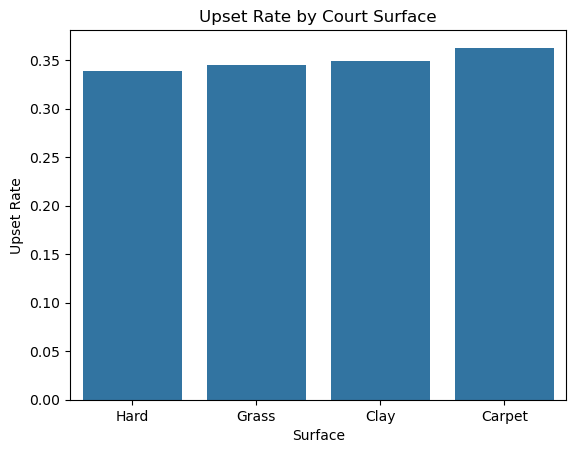

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=upset_surface.index, y=upset_surface.values)

plt.title("Upset Rate by Court Surface")
plt.xlabel("Surface")
plt.ylabel("Upset Rate")

plt.show()

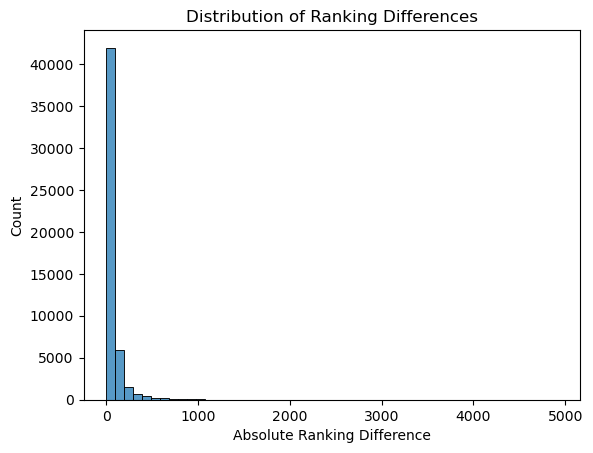

In [14]:
sns.histplot(df_clean['abs_rank_diff'], bins=50)

plt.title("Distribution of Ranking Differences")
plt.xlabel("Absolute Ranking Difference")
plt.ylabel("Count")

plt.show()

In [15]:
df_clean['favorite_wins'] = (
    ((df_clean['Rank_1'] < df_clean['Rank_2']) & (df_clean['Winner'] == df_clean['Player_1'])) |
    ((df_clean['Rank_2'] < df_clean['Rank_1']) & (df_clean['Winner'] == df_clean['Player_2']))
)

/tmp/ipykernel_879/1376506743.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rank_pred = df_clean.groupby('rank_bin')['favorite_wins'].mean()


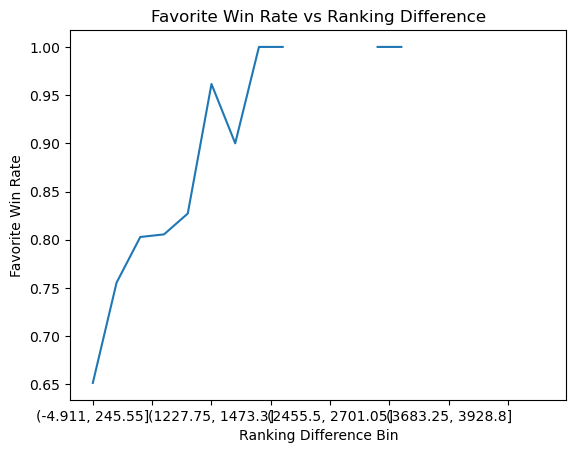

In [16]:
df_clean['rank_bin'] = pd.cut(df_clean['abs_rank_diff'], bins=20)

rank_pred = df_clean.groupby('rank_bin')['favorite_wins'].mean()

rank_pred.plot()

plt.title("Favorite Win Rate vs Ranking Difference")
plt.xlabel("Ranking Difference Bin")
plt.ylabel("Favorite Win Rate")

plt.show()

In [17]:
surface_pred = df_clean.groupby('Surface')['favorite_wins'].mean()

print(surface_pred)

Surface
Carpet    0.637191
Clay      0.650827
Grass     0.655221
Hard      0.661616
Name: favorite_wins, dtype: float64


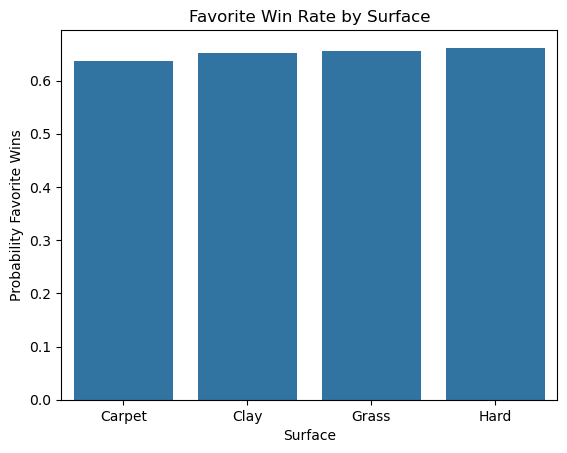

In [18]:
sns.barplot(x=surface_pred.index, y=surface_pred.values)

plt.title("Favorite Win Rate by Surface")
plt.ylabel("Probability Favorite Wins")
plt.xlabel("Surface")

plt.show()

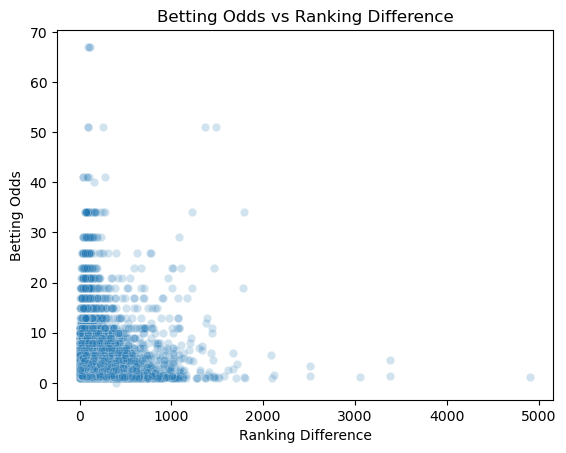

In [19]:
sns.scatterplot(
    x='abs_rank_diff',
    y='Odd_1',
    data=df_clean,
    alpha=0.2
)

plt.title("Betting Odds vs Ranking Difference")
plt.xlabel("Ranking Difference")
plt.ylabel("Betting Odds")

plt.show()

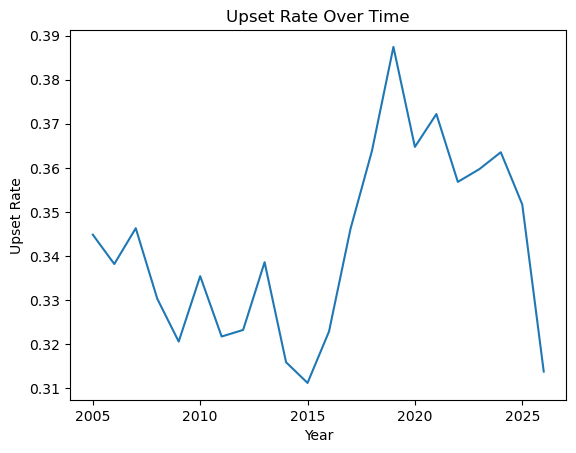

In [20]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

df_clean['Year'] = df_clean['Date'].dt.year

year_upsets = df_clean.groupby('Year')['upset'].mean()

year_upsets.plot()

plt.title("Upset Rate Over Time")
plt.ylabel("Upset Rate")
plt.xlabel("Year")

plt.show()

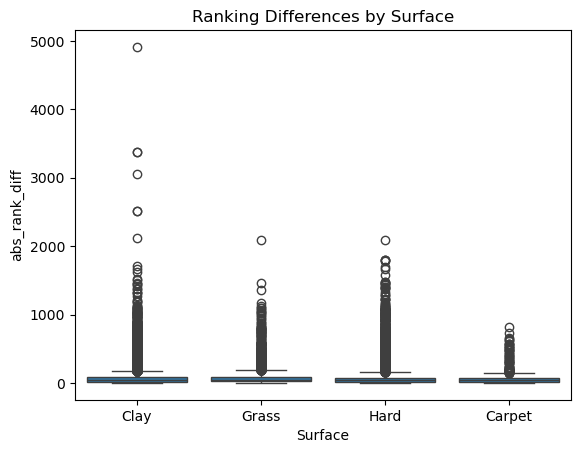

In [21]:
sns.boxplot(
    x='Surface',
    y='abs_rank_diff',
    data=df_clean
)

plt.title("Ranking Differences by Surface")
plt.show()

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [22]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them